# 1. Objetivo

Este notebook consolida a etapa de **modelagem** do Tech Challenge, substituindo os antigos `02_preprocessamento_ml.ipynb`, `03_modelo_baseline.ipynb` e `04_comparacao_modelos.ipynb` — que ficaram repetitivos entre si, pois cada um recarregava os dados e recriava os mesmos cenários. Aqui, cada etapa acontece **uma única vez**:

- preparação dos dados para Machine Learning: separação de `X`/`y` e definição dos dois cenários de modelagem (`referencia` e `comportamental`);
- definição de cinco algoritmos candidatos: Regressão Logística, Árvore de Decisão, Random Forest, Gradient Boosting e XGBoost;
- treinamento e comparação dos cinco algoritmos nos dois cenários, com validação cruzada estratificada, via `executar_comparacao()` (`src/model_comparison.py`);
- seleção do melhor modelo por cenário e diagnóstico (classification_report, matriz de confusão, gap treino/CV/teste).

**Importante:** a Regressão Logística já é um dos cinco modelos comparados dentro de `executar_comparacao()` — ela **não** é treinada de novo manualmente como "baseline". O baseline do projeto passa a ser simplesmente a leitura da linha `Logistic Regression` do cenário `comportamental` no resultado da comparação (Seção 8).

Toda a lógica reutilizável (preparação de dados, pipelines, cenários, comparação de modelos e avaliação) está centralizada em `src/`; este notebook só importa, executa e interpreta.

## 2. Importações

Bibliotecas padrão, de terceiros e código do projeto (`src/`), em um único bloco. O `XGBClassifier` é usado indiretamente através do wrapper `XGBoostComEncodingDeAlvo` (`src/model_training.py`), que resolve a exigência do XGBoost de receber `y` codificado como inteiros sem alterar o restante do projeto.

In [1]:
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

sys.path.append("..")
from src.model_comparison import executar_comparacao
from src.model_training import (
    META_ACCURACY,
    N_SPLITS_CV,
    ORDEM_NIVEIS_OBESIDADE,
    RANDOM_STATE,
    TARGET,
    XGBoostComEncodingDeAlvo,
    carregar_dados_silver,
    criar_cenarios_modelagem,
    dividir_treino_teste,
    separar_features_target,
)

## 3. Configurações iniciais

`RANDOM_STATE`, `TARGET`, `ORDEM_NIVEIS_OBESIDADE`, `N_SPLITS_CV` e `META_ACCURACY` são definidos uma única vez em `src/model_training.py` e reutilizados por toda a modelagem (preparação, definição de modelos e comparação), garantindo que a mesma configuração seja aplicada de forma consistente.

In [2]:
print(f"RANDOM_STATE: {RANDOM_STATE}")
print(f"TARGET: {TARGET}")
print(f"ORDEM_NIVEIS_OBESIDADE: {ORDEM_NIVEIS_OBESIDADE}")
print(f"N_SPLITS_CV: {N_SPLITS_CV}")
print(f"META_ACCURACY: {META_ACCURACY:.0%}")

pd.set_option("display.max_columns", None)
sns.set_theme(style="white")

RANDOM_STATE: 42
TARGET: ds_nivel_obesidade
ORDEM_NIVEIS_OBESIDADE: ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
N_SPLITS_CV: 5
META_ACCURACY: 75%


## 4. Carregamento dos dados

Carregamos a camada Silver (`data/silver/obesity_tratado.csv`) uma única vez, com `carregar_dados_silver()`. É a mesma base já validada, limpa e enriquecida com as features comportamentais na etapa de EDA (`01_eda.ipynb`).

In [3]:
dados_silver = carregar_dados_silver()
dados_silver.shape

(2087, 21)

## 5. Preparação para modelagem

Separamos `X`/`y` com `separar_features_target()` e, em seguida, construímos os dois cenários de modelagem com `criar_cenarios_modelagem()`:

- **`referencia`**: mantém todos os atributos, incluindo `nr_altura`, `nr_peso` e `nr_imc`. Como o alvo deste dataset é originalmente derivado de faixas de IMC (`peso / altura²`), essas três colunas quase determinam o alvo sozinhas — este cenário funciona como teto de performance/checagem de sanidade, não como candidato a produção.
- **`comportamental`**: remove essas três colunas, restando apenas hábitos alimentares, atividade física e dados demográficos. É o cenário clinicamente relevante para o hospital, já que o objetivo de negócio é apoiar a equipe médica a partir de hábitos de vida, não recalcular o IMC que o paciente já tem.

O split treino/teste **não** é feito manualmente aqui: ele acontece dentro de `executar_comparacao()` (Seção 7), que garante — via `assert` — que os dois cenários compartilham exatamente a mesma divisão de linhas, para que a comparação entre eles seja justa.

In [4]:
X, y = separar_features_target(dados_silver, target=TARGET)

cenarios = criar_cenarios_modelagem(X)

for nome_cenario, X_cenario in cenarios.items():
    print(f"Cenário '{nome_cenario}': {X_cenario.shape[1]} colunas -> {list(X_cenario.columns)}")

Cenário 'referencia': 20 colunas -> ['ds_genero', 'nr_idade', 'nr_altura', 'nr_peso', 'fl_historico_familiar_sobrepeso', 'fl_consumo_calorico_frequente', 'cd_consumo_de_vegetais', 'cd_numero_refeicoes_principais', 'ds_lanches_entre_refeicoes', 'fl_fumante', 'cd_consumo_agua', 'fl_monitora_calorias', 'cd_frequencia_atividade_fisica', 'cd_tempo_uso_eletronicos', 'ds_consumo_alcool', 'ds_meio_transporte', 'nr_imc', 'fl_transporte_ativo', 'ds_faixa_etaria', 'ds_consumo_alcool_agrupado']
Cenário 'comportamental': 17 colunas -> ['ds_genero', 'nr_idade', 'fl_historico_familiar_sobrepeso', 'fl_consumo_calorico_frequente', 'cd_consumo_de_vegetais', 'cd_numero_refeicoes_principais', 'ds_lanches_entre_refeicoes', 'fl_fumante', 'cd_consumo_agua', 'fl_monitora_calorias', 'cd_frequencia_atividade_fisica', 'cd_tempo_uso_eletronicos', 'ds_consumo_alcool', 'ds_meio_transporte', 'fl_transporte_ativo', 'ds_faixa_etaria', 'ds_consumo_alcool_agrupado']


## 6. Definição dos modelos

Testamos cinco algoritmos nos dois cenários: **Regressão Logística**, **Árvore de Decisão**, **Random Forest**, **Gradient Boosting** e **XGBoost**. Todos usam `random_state=RANDOM_STATE` (importado de `src/model_training.py`) — nenhuma semente é hardcoded neste notebook.

**Particularidade do XGBoost:** diferente dos demais algoritmos (que aceitam `y` como texto, ex.: `"Normal_Weight"`), o `XGBClassifier` exige que o alvo seja codificado como inteiros. Por isso, usamos `XGBoostComEncodingDeAlvo` (`src/model_training.py`) — um wrapper que aplica um `LabelEncoder` internamente antes de treinar e reverte a codificação em `predict()`, para que o XGBoost participe de `executar_comparacao()` do mesmo jeito que os demais estimadores, sem exigir nenhuma alteração em `src/model_evaluation.py` ou `src/model_comparison.py`.

In [5]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBoostComEncodingDeAlvo(random_state=RANDOM_STATE),
}

list(modelos.keys())

['Logistic Regression',
 'Decision Tree',
 'Random Forest',
 'Gradient Boosting',
 'XGBoost']

## 7. Comparação

`executar_comparacao()` (`src/model_comparison.py`) treina e avalia, de forma padronizada, todas as combinações de cenário x modelo: para cada uma, roda validação cruzada estratificada (`N_SPLITS_CV` folds) sobre `X_train`/`y_train`, treina a pipeline final e a avalia em `X_test`/`y_test` (com `labels=ORDEM_NIVEIS_OBESIDADE`). Internamente, a função garante — via `assert` — que os dois cenários compartilham exatamente a mesma divisão de treino/teste.

A função retorna uma tupla: um DataFrame resumo (`resultado`) e um dicionário (`detalhes`), indexado por `(cenario, modelo)`, com a pipeline já treinada e o diagnóstico completo de teste — para uso nas próximas seções sem re-treinar nada.

**A validação cruzada (`accuracy_cv_media`/`f1_macro_cv_media`) é o critério de seleção do melhor modelo; as métricas de teste são apenas informação complementar.**

In [6]:
resultado, detalhes = executar_comparacao(
    cenarios=cenarios,
    y=y,
    modelos=modelos,
)
resultado

,cenario,modelo,accuracy_cv_media,accuracy_cv_desvio,f1_macro_cv_media,f1_macro_cv_desvio,accuracy_teste,f1_macro_teste,fit_time
0,referencia,Logistic Regression,0.899338,0.022703,0.894821,0.023886,0.918660,0.915183,0.226370
1,referencia,Decision Tree,0.969441,0.003505,0.968707,0.003259,0.980861,0.980391,0.030276
2,referencia,Random Forest,0.980232,0.006441,0.979263,0.006703,0.976077,0.975247,0.266545
3,referencia,Gradient Boosting,0.973635,0.002269,0.973176,0.002324,0.980861,0.980095,2.369940
4,referencia,XGBoost,0.979026,0.004257,0.978450,0.004651,0.988038,0.987502,1.494590
5,comportamental,Logistic Regression,0.607540,0.032639,0.581662,0.035337,0.622010,0.588067,0.531223
6,comportamental,Decision Tree,0.726781,0.008394,0.717475,0.010577,0.717703,0.709633,0.056276
7,comportamental,Random Forest,0.796289,0.006171,0.789098,0.007303,0.794258,0.787097,0.257989
8,comportamental,Gradient Boosting,0.757933,0.020061,0.750872,0.023137,0.765550,0.757677,4.643619
9,comportamental,XGBoost,0.809466,0.009409,0.803079,0.009721,0.775120,0.769354,2.723155


## 8. Ranking e checagem da meta

Ordenamos as combinações por `accuracy_cv_media`/`f1_macro_cv_media` — as métricas de validação cruzada, critério de seleção do projeto — e marcamos, com duas colunas booleanas, quais combinações atingem a meta de 75% de acurácia (`META_ACCURACY`): `bate_meta_cv` (pela validação cruzada, usada para decidir) e `bate_meta_teste` (pelo teste, apenas para conferência).

Em seguida, destacamos explicitamente a linha `Logistic Regression` do cenário `comportamental`: é o **baseline** de comparação do projeto. Ela já está no resultado de `executar_comparacao()` — não é treinada de novo aqui.

In [7]:
ranking = resultado.sort_values(
    by=["accuracy_cv_media", "f1_macro_cv_media"],
    ascending=False,
).reset_index(drop=True)

ranking["bate_meta_cv"] = ranking["accuracy_cv_media"] >= META_ACCURACY
ranking["bate_meta_teste"] = ranking["accuracy_teste"] >= META_ACCURACY

ranking

,cenario,modelo,accuracy_cv_media,accuracy_cv_desvio,f1_macro_cv_media,f1_macro_cv_desvio,accuracy_teste,f1_macro_teste,fit_time,bate_meta_cv,bate_meta_teste
0,referencia,Random Forest,0.980232,0.006441,0.979263,0.006703,0.976077,0.975247,0.266545,True,True
1,referencia,XGBoost,0.979026,0.004257,0.978450,0.004651,0.988038,0.987502,1.494590,True,True
2,referencia,Gradient Boosting,0.973635,0.002269,0.973176,0.002324,0.980861,0.980095,2.369940,True,True
3,referencia,Decision Tree,0.969441,0.003505,0.968707,0.003259,0.980861,0.980391,0.030276,True,True
4,referencia,Logistic Regression,0.899338,0.022703,0.894821,0.023886,0.918660,0.915183,0.226370,True,True
5,comportamental,XGBoost,0.809466,0.009409,0.803079,0.009721,0.775120,0.769354,2.723155,True,True
6,comportamental,Random Forest,0.796289,0.006171,0.789098,0.007303,0.794258,0.787097,0.257989,True,True
7,comportamental,Gradient Boosting,0.757933,0.020061,0.750872,0.023137,0.765550,0.757677,4.643619,True,True
8,comportamental,Decision Tree,0.726781,0.008394,0.717475,0.010577,0.717703,0.709633,0.056276,False,False
9,comportamental,Logistic Regression,0.607540,0.032639,0.581662,0.035337,0.622010,0.588067,0.531223,False,False


In [8]:
baseline = ranking[
    (ranking["cenario"] == "comportamental") & (ranking["modelo"] == "Logistic Regression")
].iloc[0]

print("Baseline do projeto (Regressão Logística, cenário comportamental):")
print(
    f"  accuracy_cv_media = {baseline['accuracy_cv_media']:.4f} | "
    f"f1_macro_cv_media = {baseline['f1_macro_cv_media']:.4f} | "
    f"accuracy_teste = {baseline['accuracy_teste']:.4f} | "
    f"bate_meta_cv = {baseline['bate_meta_cv']}"
)

Baseline do projeto (Regressão Logística, cenário comportamental):
  accuracy_cv_media = 0.6075 | f1_macro_cv_media = 0.5817 | accuracy_teste = 0.6220 | bate_meta_cv = False


## 9. Diagnóstico do melhor modelo por cenário

Selecionamos o melhor modelo de cada cenário a partir do `ranking` (já ordenado pela validação cruzada) e recuperamos, para cada um, o `classification_report` e a matriz de confusão diretamente do dicionário `detalhes` (calculado na Seção 7, com a ordem clínica de `ORDEM_NIVEIS_OBESIDADE`) — sem re-treinar nenhuma pipeline.

In [9]:
melhor_por_cenario = ranking.groupby("cenario", as_index=False).first()
melhor_por_cenario

,cenario,modelo,accuracy_cv_media,accuracy_cv_desvio,f1_macro_cv_media,f1_macro_cv_desvio,accuracy_teste,f1_macro_teste,fit_time,bate_meta_cv,bate_meta_teste
0,comportamental,XGBoost,0.809466,0.009409,0.803079,0.009721,0.775120,0.769354,2.723155,True,True
1,referencia,Random Forest,0.980232,0.006441,0.979263,0.006703,0.976077,0.975247,0.266545,True,True


In [10]:
for _, linha in melhor_por_cenario.iterrows():
    nome_cenario = linha["cenario"]
    nome_modelo = linha["modelo"]

    avaliacao_teste = detalhes[(nome_cenario, nome_modelo)]["avaliacao_teste"]

    print(f"{'=' * 60}")
    print(f"Melhor modelo do cenário '{nome_cenario}': {nome_modelo}")
    print(f"{'=' * 60}")
    print(
        f"Validação cruzada -> accuracy: {linha['accuracy_cv_media']:.4f} "
        f"± {linha['accuracy_cv_desvio']:.4f} | "
        f"F1-macro: {linha['f1_macro_cv_media']:.4f} "
        f"± {linha['f1_macro_cv_desvio']:.4f}"
    )
    print(
        f"Teste (informativo) -> accuracy: {linha['accuracy_teste']:.4f} | "
        f"F1-macro: {linha['f1_macro_teste']:.4f}"
    )
    print("\nClassification report (teste):")
    print(avaliacao_teste["classification_report"])
    print()

Melhor modelo do cenário 'comportamental': XGBoost
Validação cruzada -> accuracy: 0.8095 ± 0.0094 | F1-macro: 0.8031 ± 0.0097
Teste (informativo) -> accuracy: 0.7751 | F1-macro: 0.7694

Classification report (teste):
                     precision    recall  f1-score   support

Insufficient_Weight       0.84      0.87      0.85        53
      Normal_Weight       0.59      0.58      0.58        57
 Overweight_Level_I       0.67      0.69      0.68        55
Overweight_Level_II       0.78      0.60      0.68        58
     Obesity_Type_I       0.73      0.76      0.74        70
    Obesity_Type_II       0.83      0.92      0.87        60
   Obesity_Type_III       0.97      0.98      0.98        65

           accuracy                           0.78       418
          macro avg       0.77      0.77      0.77       418
       weighted avg       0.77      0.78      0.77       418


Melhor modelo do cenário 'referencia': Random Forest
Validação cruzada -> accuracy: 0.9802 ± 0.0064 | F1-mac

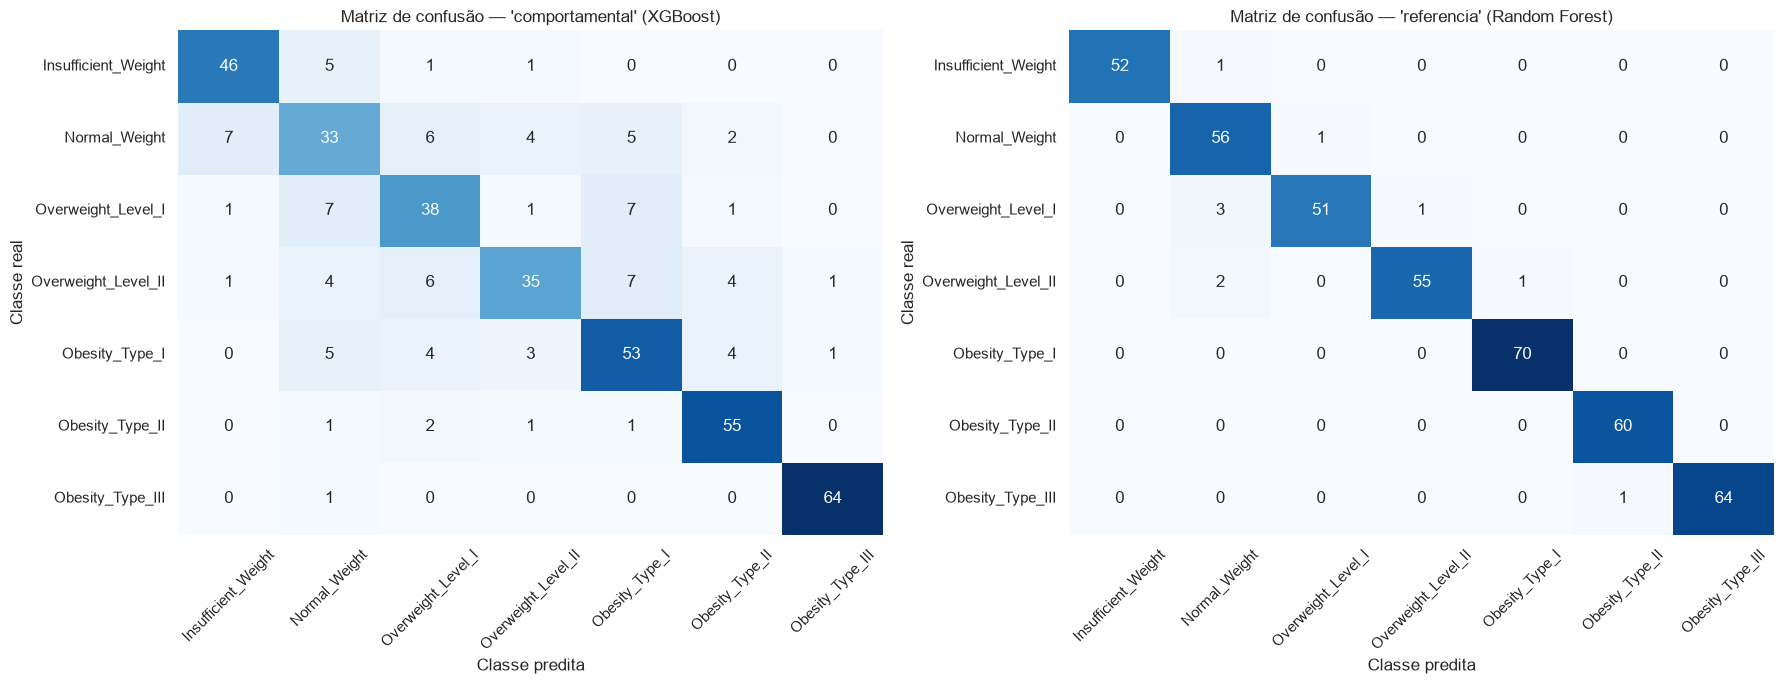

In [11]:
fig, eixos = plt.subplots(1, 2, figsize=(18, 7))

for eixo, (_, linha) in zip(eixos, melhor_por_cenario.iterrows()):
    nome_cenario = linha["cenario"]
    nome_modelo = linha["modelo"]
    matriz_confusao = detalhes[(nome_cenario, nome_modelo)]["avaliacao_teste"]["matriz_confusao"]

    sns.heatmap(
        matriz_confusao,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=ORDEM_NIVEIS_OBESIDADE,
        yticklabels=ORDEM_NIVEIS_OBESIDADE,
        cbar=False,
        ax=eixo,
    )
    eixo.set_title(f"Matriz de confusão — '{nome_cenario}' ({nome_modelo})")
    eixo.set_xlabel("Classe predita")
    eixo.set_ylabel("Classe real")
    eixo.tick_params(axis="x", rotation=45)
    eixo.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

### 9.1 Checagem de overfitting no cenário `comportamental`

Para o melhor modelo do cenário `comportamental`, comparamos a accuracy de treino (in-sample, `.score(X_train, y_train)` sobre a pipeline já treinada, sem novo `fit`) com a accuracy da validação cruzada e a accuracy de teste. Um gap grande entre treino e as demais indicaria memorização do treino em vez de generalização.

`executar_comparacao()` não expõe `X_train`/`y_train` diretamente, então reconstruímos aqui a mesma divisão (mesmo `RANDOM_STATE`/`TEST_SIZE` usados internamente) apenas para obter `X_train`/`y_train` — nenhum modelo é re-treinado, a pipeline usada em `.score()` é a mesma já treinada em `detalhes`.

In [12]:
linha_comportamental = melhor_por_cenario.loc[melhor_por_cenario["cenario"] == "comportamental"].iloc[0]
melhor_modelo_comportamental = linha_comportamental["modelo"]

X_train_comportamental, X_test_comportamental, y_train_comportamental, y_test_comportamental = dividir_treino_teste(
    cenarios["comportamental"], y
)

pipeline_comportamental = detalhes[("comportamental", melhor_modelo_comportamental)]["pipeline"]
accuracy_treino_comportamental = pipeline_comportamental.score(X_train_comportamental, y_train_comportamental)

tabela_overfitting = pd.DataFrame(
    {
        "Etapa": ["Treino (in-sample)", "Validação cruzada (média)", "Teste"],
        "Accuracy": [
            accuracy_treino_comportamental,
            linha_comportamental["accuracy_cv_media"],
            linha_comportamental["accuracy_teste"],
        ],
    }
)

print(f"Melhor modelo do cenário 'comportamental': {melhor_modelo_comportamental}\n")
tabela_overfitting.round(4)

Melhor modelo do cenário 'comportamental': XGBoost



,Etapa,Accuracy
0,Treino (in-sample),0.9940
1,Validação cruzada (média),0.8095
2,Teste,0.7751


## 10. Conclusões

**Baseline (Regressão Logística) vs. algoritmos mais robustos:** no cenário `comportamental`, o baseline (Regressão Logística) fica em accuracy_cv_media = 60,8% ± 3,3 p.p. (f1_macro_cv_media = 58,2%) — bem abaixo da meta. Os quatro algoritmos mais robustos superam o baseline por margem larga: Árvore de Decisão (72,7%), Gradient Boosting (75,8%), Random Forest (79,6%) e XGBoost (81,0% ± 0,9 p.p.), o melhor pela validação cruzada. O ganho vem da capacidade desses modelos de capturar relações não lineares entre hábitos de vida que a Regressão Logística (linear) não representa.

**Meta de 75% de acurácia:** no cenário `comportamental` (o clinicamente relevante, sem métricas antropométricas), três algoritmos batem a meta pela validação cruzada — XGBoost (81,0%), Random Forest (79,6%) e Gradient Boosting (75,8%) — enquanto Árvore de Decisão (72,7%) e o baseline (60,8%) não batem. O cenário `referencia` bate a meta com folga em todos os algoritmos (89,9% a 98,0%), mas segue sendo apenas teto de performance/checagem de sanidade — não um candidato a produção, por reaprender a fórmula do IMC em vez de agregar valor clínico.

**Gap validação cruzada vs. teste:** no cenário `referencia`, o gap é pequeno e até favorável ao teste em alguns modelos (ex.: XGBoost: 97,9% CV vs. 98,8% teste), sem sinal de overfitting. No cenário `comportamental`, o **Random Forest** tem o gap mais estável (79,6% CV vs. 79,4% teste, diferença de ~0,2 p.p.), enquanto o **XGBoost** (melhor pela CV) tem um gap maior (81,0% CV vs. 77,5% teste, ~3,4 p.p.) — maior que o desvio-padrão entre folds (0,9 p.p.). A checagem adicional de overfitting da Seção 9.1 reforça esse ponto: a accuracy de treino (in-sample) do XGBoost no cenário `comportamental` é 99,4%, muito acima da accuracy de validação cruzada (81,0%) e de teste (77,5%) — um gap de quase 22 p.p. entre treino e teste, sinal claro de que o XGBoost, com hiperparâmetros padrão (sem tuning), está memorizando parte do conjunto de treino. Isso não invalida sua seleção pela validação cruzada (que é calculada em dados não vistos dentro do treino), mas é um alerta para produção.

**Tempo de treinamento como critério de desempate:** no cenário `comportamental`, o XGBoost (fit_time ≈ 2,72s) foi o modelo mais lento entre os que batem a meta, cerca de **10,6 vezes mais lento** que o Random Forest (fit_time ≈ 0,26s) para uma vantagem de apenas ~1,3 p.p. de accuracy_cv_media. Combinando desempenho de validação cruzada, estabilidade (gap CV-teste) e custo de treino, o **Random Forest é um candidato pelo menos tão forte quanto o XGBoost** para produção neste cenário.

**Recall de `Overweight_Level_II` (classe mais difícil no baseline):** no baseline (Regressão Logística, cenário comportamental), o recall dessa classe é de apenas **0,16** — o modelo praticamente não identifica esses pacientes. No melhor modelo deste notebook (XGBoost, cenário comportamental), o recall da mesma classe sobe para **0,60** — quase 4x maior. É a evidência mais concreta de que os algoritmos mais robustos corrigem especificamente a maior fraqueza do baseline: distinguir os níveis intermediários de sobrepeso/obesidade a partir de hábitos de vida.

**Recomendação final:** para o cenário `comportamental` (o que interessa ao hospital), a meta de 75% de acurácia foi atingida — o baseline está superado. Entre os candidatos que batem a meta, o **Random Forest** é a recomendação para seguir à etapa de deploy no Streamlit: desempenho de validação cruzada muito próximo do XGBoost (79,6% vs. 81,0%), gap CV-teste bem menor (indicando generalização mais estável e menos risco de overfitting) e treino ~10,6x mais rápido — um equilíbrio melhor entre desempenho, robustez e custo do que o "melhor" modelo pelo critério estrito de `accuracy_cv_media`.